# Load data for exploration

## Load monomer dataset

In [ ]:
from pathlib import Path
from rdkit import Chem

from src.utils.dataIO import read_monomer_data


DATA_DIR : Path = Path('src/monomer_data')
DATA_PATHNAME : str = 'PolyID_master_unique.csv'

# load and parse monomer data file from disc
input_data_path = DATA_DIR / DATA_PATHNAME
monomer_df = read_monomer_data([input_data_path])[0]
monomer_df.set_index(monomer_df.columns[0], inplace=True) # alternative to index_cols arg in read function

# grouping chemistries by labelled polymerization mechanism
grouper = monomer_df.groupby('mechanism_labelled', as_index=False)
sample = grouper.sample(n=1)
print(grouper.groups.keys())

# generate chemically-unique counterpart
# monomer_df_unique = monomer_df.drop_duplicates('smiles_canonical')
# print(len(monomer_df_unique))

## Some other stuff

## Load reaction mechanism templates

In [ ]:
from src.utils.dataIO import read_rxn_mapping_data
from polymerist.rdutils.reactions.reactions import AnnotatedReaction


RXN_DIR : Path = Path('src/reactions')
# RXN_PATHNAME : str = 'rxn_smarts.json'
RXN_PATHNAME : str = 'rxns_polyID.json'

show : bool = not True

# load reactions
rxns : dict[str, AnnotatedReaction] = {}
for rxnname, smarts in read_rxn_mapping_data(RXN_DIR / RXN_PATHNAME).items():
    rxn = AnnotatedReaction.from_smarts(smarts)
    rxns[rxnname] = rxn 
    if show:
        print(rxnname)
        display(rxn)

# Implementing mechanism perception

In [ ]:
from typing import Container, Optional, Union
from rdkit.Chem.rdmolops import AROMATICITY_MDL, SANITIZE_ALL

from polymerist.rdutils.sanitization import sanitize_mol
from polymerist.rdutils.reactions.reactors import PolymerizationReactor


def perceive_mechanisms(
        mols : Union[Chem.Mol, Container[Chem.Mol]],
        rxns : dict[str, AnnotatedReaction],
        allow_resampling : bool=False,
    ) -> set[str]:
    '''NOTE: can test for autopolymerizations by seeing if result is returned both with an without resampling (auto) or just without (hetero)'''
    if isinstance(mols, Chem.Mol):
        mols = list[mols] # wrap singleton molecules into container
    
    return set(
        rxnname
            for rxnname, rxn in rxns.items()
                if rxn.has_reactable_subset(mols, allow_resampling=allow_resampling)
    )

In [ ]:
import logging

sample = grouper.sample(n=1)
for i, row in sample.iterrows():
    print('='*50)
    monomer_mol_combined = Chem.MolFromSmiles(row.smiles_explicit, sanitize=False)
    sanitize_mol(monomer_mol_combined, sanitize_ops=SANITIZE_ALL, aromaticity_model=AROMATICITY_MDL, in_place=True)
    display(monomer_mol_combined)
    monomer_mols = Chem.GetMolFrags(monomer_mol_combined, sanitizeFrags=False, asMols=True)
    mechanism_labelled = row.mechanism_labelled # one-time lookup

    print(f'{mechanism_labelled} - {row.smiles_canonical}')
    perceived_mechanisms = perceive_mechanisms(monomer_mols, rxns=rxns, allow_resampling=True)
    n_perceived_mechanisms = len(perceived_mechanisms)
    print(perceived_mechanisms)
    
    if n_perceived_mechanisms != 1: # guard clause for explicitness (even though the desired case of exactly 1 perceived mechanism is covered implicitly)
        if n_perceived_mechanisms == 0:
            logging.error(f'NO MECHANISM PERCEIVED: Monomers are not compatible with any of the defined reaction mechanism templates, including the labelled "{mechanism_labelled}" mechanism')
        elif n_perceived_mechanisms > 1:
            logging.error(f'AMBIGUOUS MECHANISM ASSIGNMENT: Monomer are compatible with multiple different defined reaction mechanism templates, namely: {perceive_mechanisms}')
        elif n_perceived_mechanisms < 1:
            logging.info(f'INVALID MECHANISM PERCEPTION: must have perceived a non-negative number of reaction mechanism templates, not {n_perceived_mechanisms}')
        continue
        
    # guaranteed to have a unique perceived mechanism if made it this far
    (mechanism,) = perceived_mechanisms # tuple unpacking avoid mutation, and enforces the expectation that only one mechanism should have been perceived
    rxn = rxns[mechanism]
    is_autopolymerization = not rxn.has_reactable_subset(monomer_mols, allow_resampling=False) # CRITICAL that no resampling be done here; are checking that this constrasts with the initial resampling-ful check
    print(f'Autopolymerizes: {is_autopolymerization}')
    
    print(mechanism)
    if mechanism != mechanism_labelled:
        logging.warning(
            f'''MISLABELLED MECHANISM: monomers labelled in input as participating in the "{mechanism_labelled}" mechanism
            perceived to be chemically-compatible with the "{mechanism}" mechanism instead
            for monomers given by: {row.smiles_canonical}'''
        )

In [ ]:
smiles = sample.iloc[4].smiles_explicit

m = Chem.MolFromSmiles(smiles, sanitize=False)
sanitize_mol(m, sanitize_ops=SANITIZE_ALL, aromaticity_model=AROMATICITY_MDL, in_place=True)
display(m)

In [ ]:
Chem.GetMolFrags(m, asMols=True)

# Describing substruct queries

In [8]:
from polymerist.smileslib.special import SPECIAL_QUERY_MOLS

BLACKLISTED_ATOM_QUERIES : dict[str, Chem.Mol] = {
    # 'boron' : Chem.MolFromSmarts('[B]'),
    # 'phosphorus' : Chem.MolFromSmarts('[P]'),
    'sulfur'  : Chem.MolFromSmarts('[S]'),
    'silicon' : Chem.MolFromSmarts('[Si]'),
    'metal'   : SPECIAL_QUERY_MOLS['metal'],
    # 'halogen' : SPECIAL_QUERY_MOLS['halogen'],
}

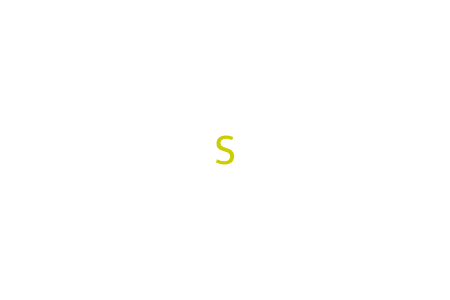

AtomType 16 = val



In [14]:
m = BLACKLISTED_ATOM_QUERIES['sulfur']
display(m)
print(m.GetAtomWithIdx(0).DescribeQuery())

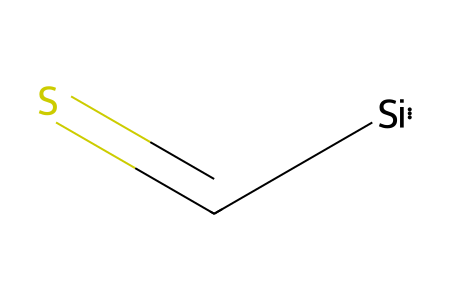

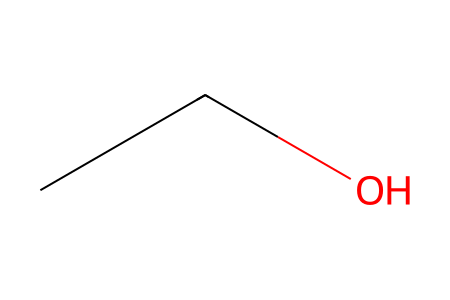

In [18]:
m1 = Chem.MolFromSmiles('[Si]-C=S')
m2 = Chem.MolFromSmiles('CCO')

display(m1)
display(m2)

In [25]:
from rdkit.Chem.rdqueries import AtomNumEqualsQueryAtom

SI = AtomNumEqualsQueryAtom(14)
S = AtomNumEqualsQueryAtom(16)
O = AtomNumEqualsQueryAtom(8)



In [29]:
any(m1.GetAtomsMatchingQuery(O))

False

# Something else